## INP

### 全部数据

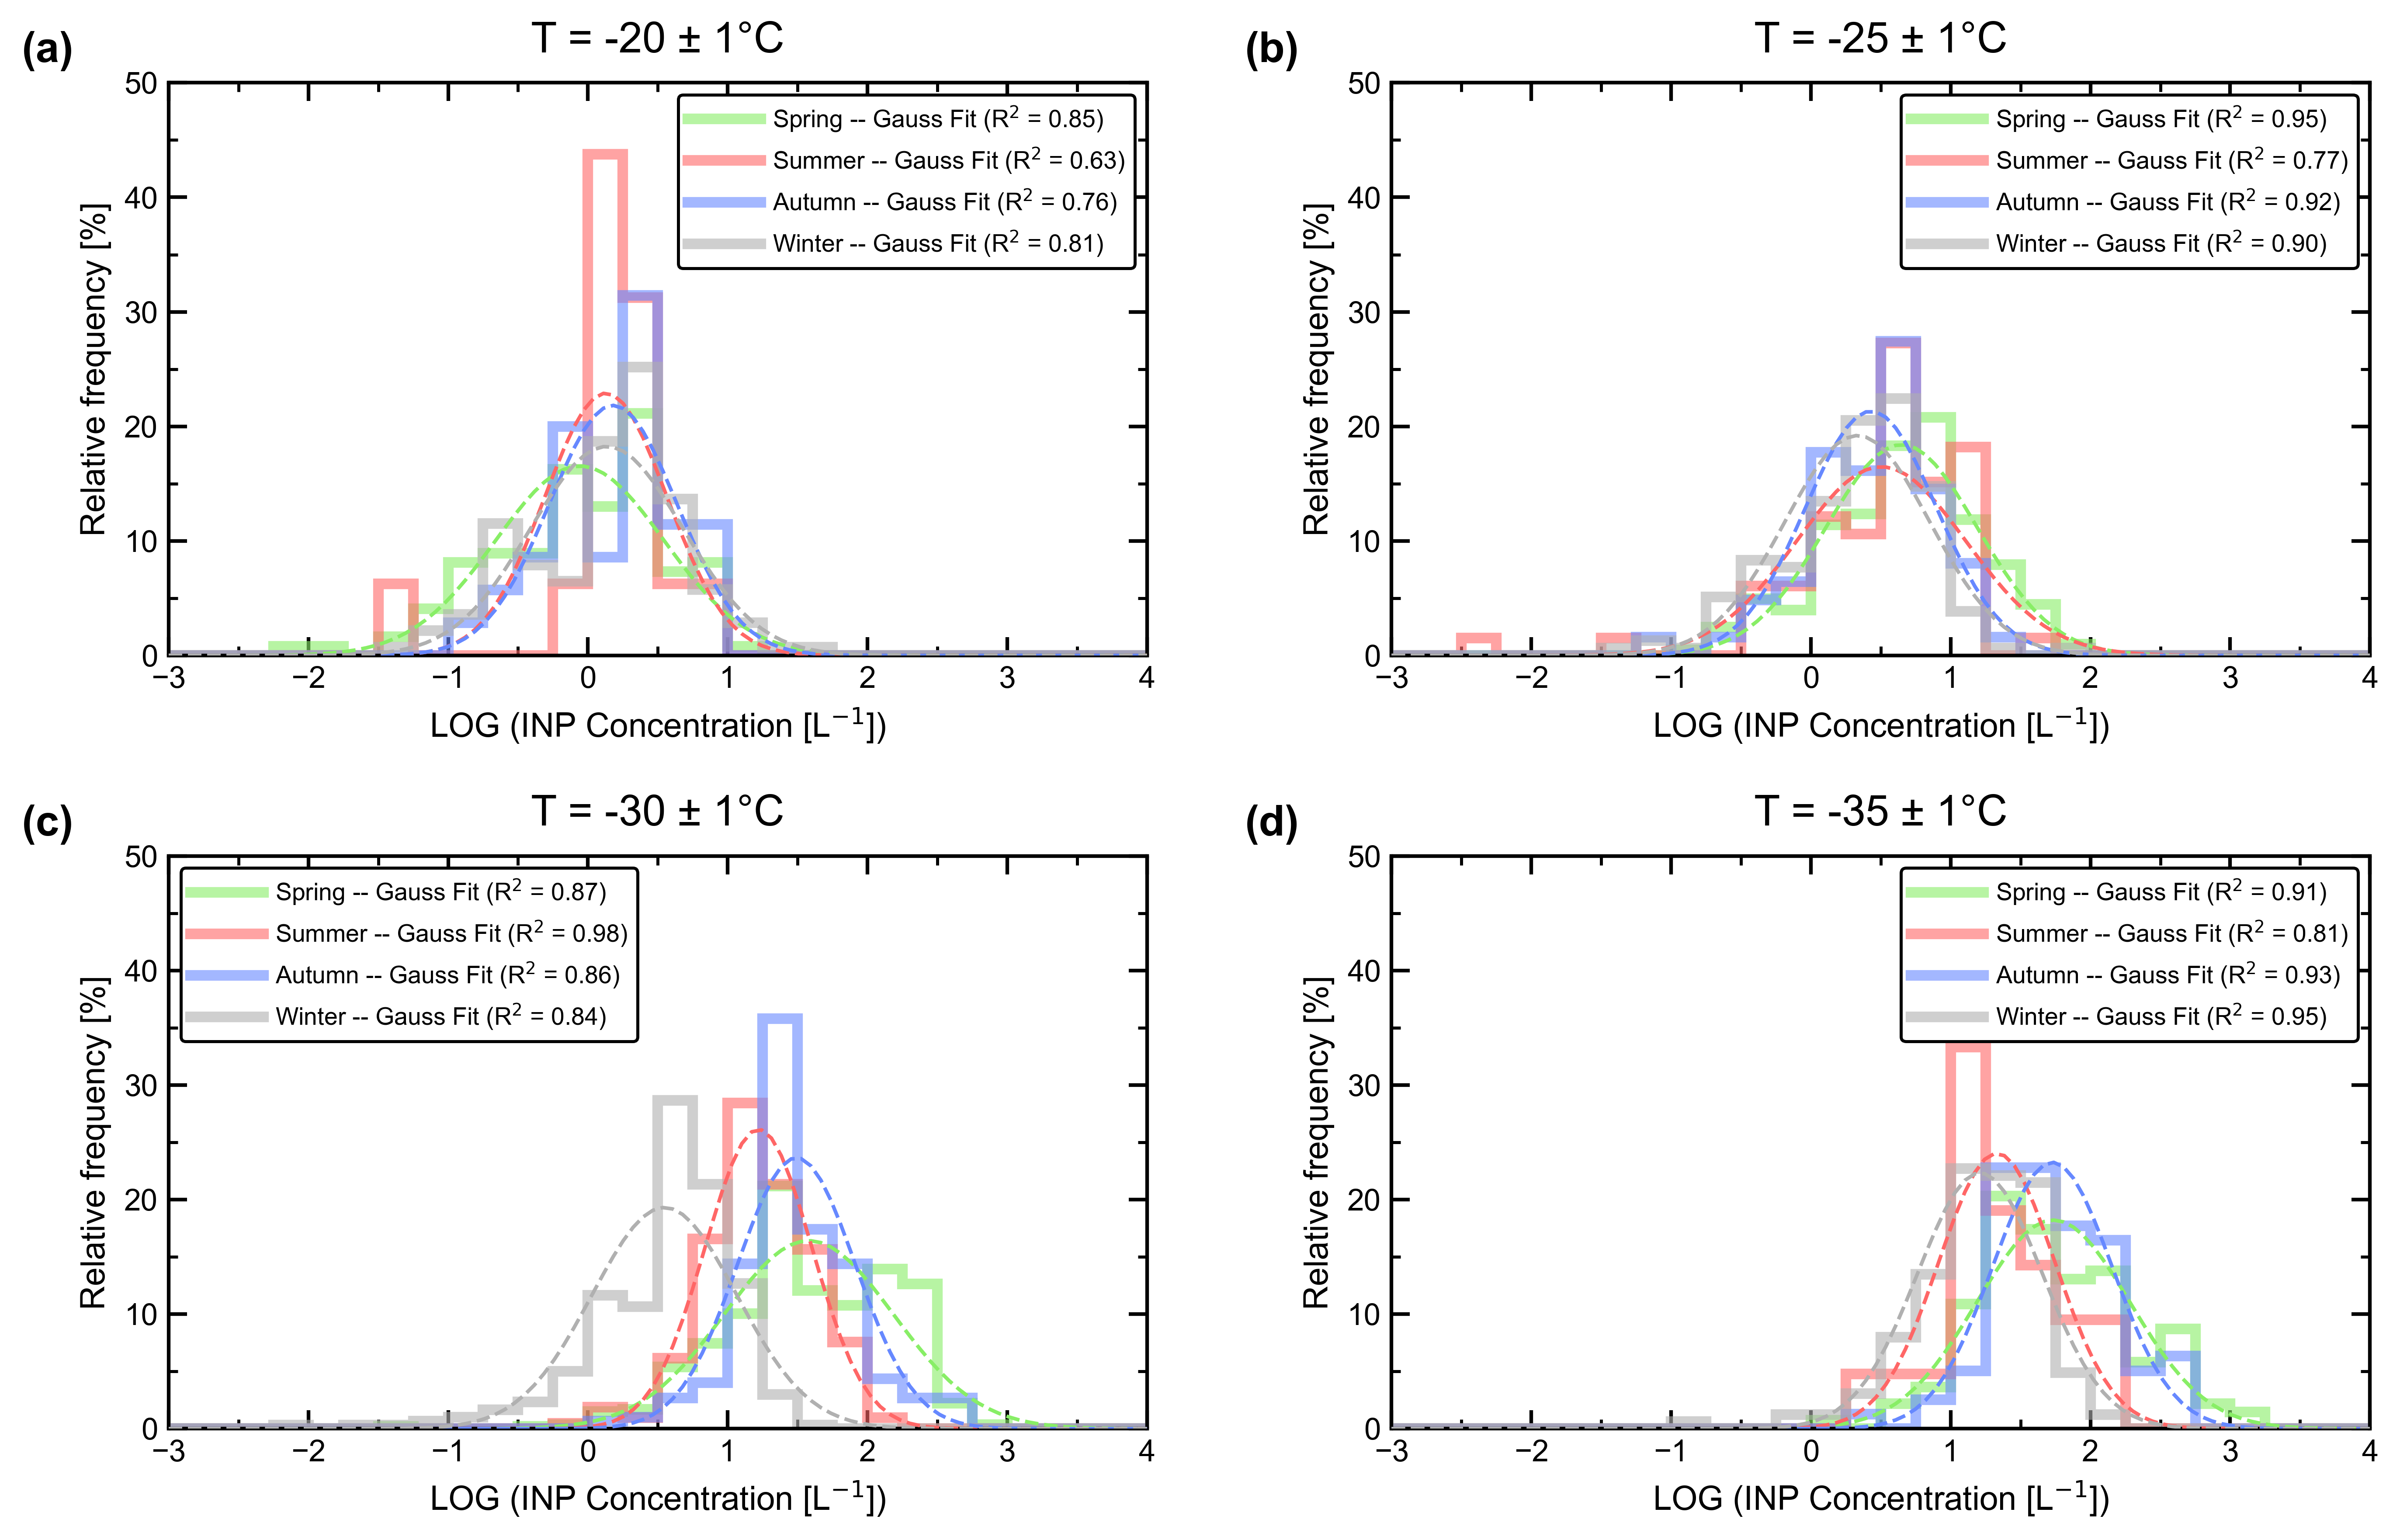

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import norm

# ==========================================
# 1. 读取数据 
# ==========================================
df = pd.read_csv(r'D:\Coding\Data\Lanzhou_cfdc\processed\N_INP(202409-202509)v2.4.1.csv')
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
target_temps = [-20, -25, -30, -35]

# ==========================================
# 2. 绘图准备与参数设置
# ==========================================
# 设置全局字体格式
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.2 # 边框加粗

# 为四个季节分配颜色
season_colors = {
    'Spring': '#88EE66', # 绿色
    'Summer': '#FF6666', # 红色
    'Autumn': '#6688FF', # 蓝色
    'Winter': '#B0B0B0', # 灰色
}

# 2行2列排版，figsize调整为 13x8 更适合A4纸竖排
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=500) 

# 将 2x2 的二维坐标轴矩阵展平为一维列表，方便用 i 索引
axes_flat = axes.flatten() 

# 调整子图间的横向(wspace)和纵向(hspace)间距
plt.subplots_adjust(wspace=0.25, hspace=0.35) 

# ==========================================
# 全局计算 X 轴的合理范围
# ==========================================
valid_global_inp = df['N_inp_net(#/L)'][df['N_inp_net(#/L)'] > 0]
global_log_data = np.log10(valid_global_inp)
x_min_global = np.floor(global_log_data.min())
x_max_global = np.ceil(global_log_data.max())
fixed_bin_width = 0.25
bins_edges = np.arange(x_min_global, x_max_global + fixed_bin_width, fixed_bin_width)
x_fit = np.linspace(x_min_global, x_max_global, 100)

# ==========================================
# 3. 循环绘制每个子图
# ==========================================
for i, t in enumerate(target_temps):
    # 使用展平后的 axes_flat
    ax = axes_flat[i] 
    df_temp = df[df['T_a(°C)'] == t]
    
    legend_handles = []
    legend_labels = []
    
    for season in seasons:
        df_season = df_temp[df_temp['season'] == season]
        if df_season.empty:
            continue
            
        valid_inp = df_season['N_inp_net(#/L)'][df_season['N_inp_net(#/L)'] > 0]
        data_log = np.log10(valid_inp)

        if len(data_log) < 3: 
            continue
            
        color = season_colors[season]
        weights = np.ones_like(data_log) / len(data_log) * 100
        
        # 绘制直方图
        counts, bins, _ = ax.hist(data_log, bins=bins_edges, weights=weights,
                                  histtype='step', linewidth=3.5, alpha=0.6, 
                                  color=color, zorder=2)
        
        # 高斯拟合
        mu, std = norm.fit(data_log)
        pdf = norm.pdf(x_fit, mu, std)
        
        bin_width = bins[1] - bins[0]
        y_fit = pdf * bin_width * 100
        
        ax.plot(x_fit, y_fit, linestyle='--', color=color, linewidth=1.2, zorder=3)
        
        # 计算 R^2
        bin_centers = (bins[:-1] + bins[1:]) / 2
        expected_counts = norm.pdf(bin_centers, mu, std) * bin_width * 100
        ss_res = np.sum((counts - expected_counts) ** 2)
        ss_tot = np.sum((counts - np.mean(counts)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        r2 = max(0, r2) 
        
        p_hist = mlines.Line2D([], [], color=color, linewidth=3.5, alpha=0.6)
        p_fit = mlines.Line2D([], [], color=color, linestyle='--', linewidth=1.2)
        legend_handles.append((p_hist))
        
        # 为了保证排版整齐，建议给season填充空格保持等长，例如使用 {season:<6}
        legend_labels.append(f"{season:<6} -- Gauss Fit (R$^2$ = {r2:.2f})")

    # ==========================================
    # 4. 子图细节美化
    # ==========================================
    ax.set_title(f'T = {t} ± 1°C', fontsize=14, pad=10)
    ax.set_xlabel('LOG (INP Concentration [L$^{-1}$])', fontsize=11)
    ax.set_ylabel('Relative frequency [%]', fontsize=11)

    ax.set_xlim(x_min_global, x_max_global)
    ax.set_ylim(0, 50)
    
    ax.tick_params(axis='both', which='major', direction='in', 
                   top=True, right=True, length=6, width=1.2, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in', 
                   top=True, right=True, length=3, width=1)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    
    ax.text(-0.15, 1.02, f'({chr(97+i)})', transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='bottom', ha='left')
    
    if legend_handles:
        ax.legend(legend_handles, legend_labels, 
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
                  fontsize=8, frameon=True, 
                  edgecolor='black', framealpha=1, borderpad=0.4, 
                  handlelength=3, handletextpad=0.5)


# 5. 保存并显示
# bbox_inches='tight' 可以自动裁剪掉多余的白边
#plt.savefig('INP_Distribution_Seasons.png', dpi=600, bbox_inches='tight')
plt.show()

### 仅含显著数据点

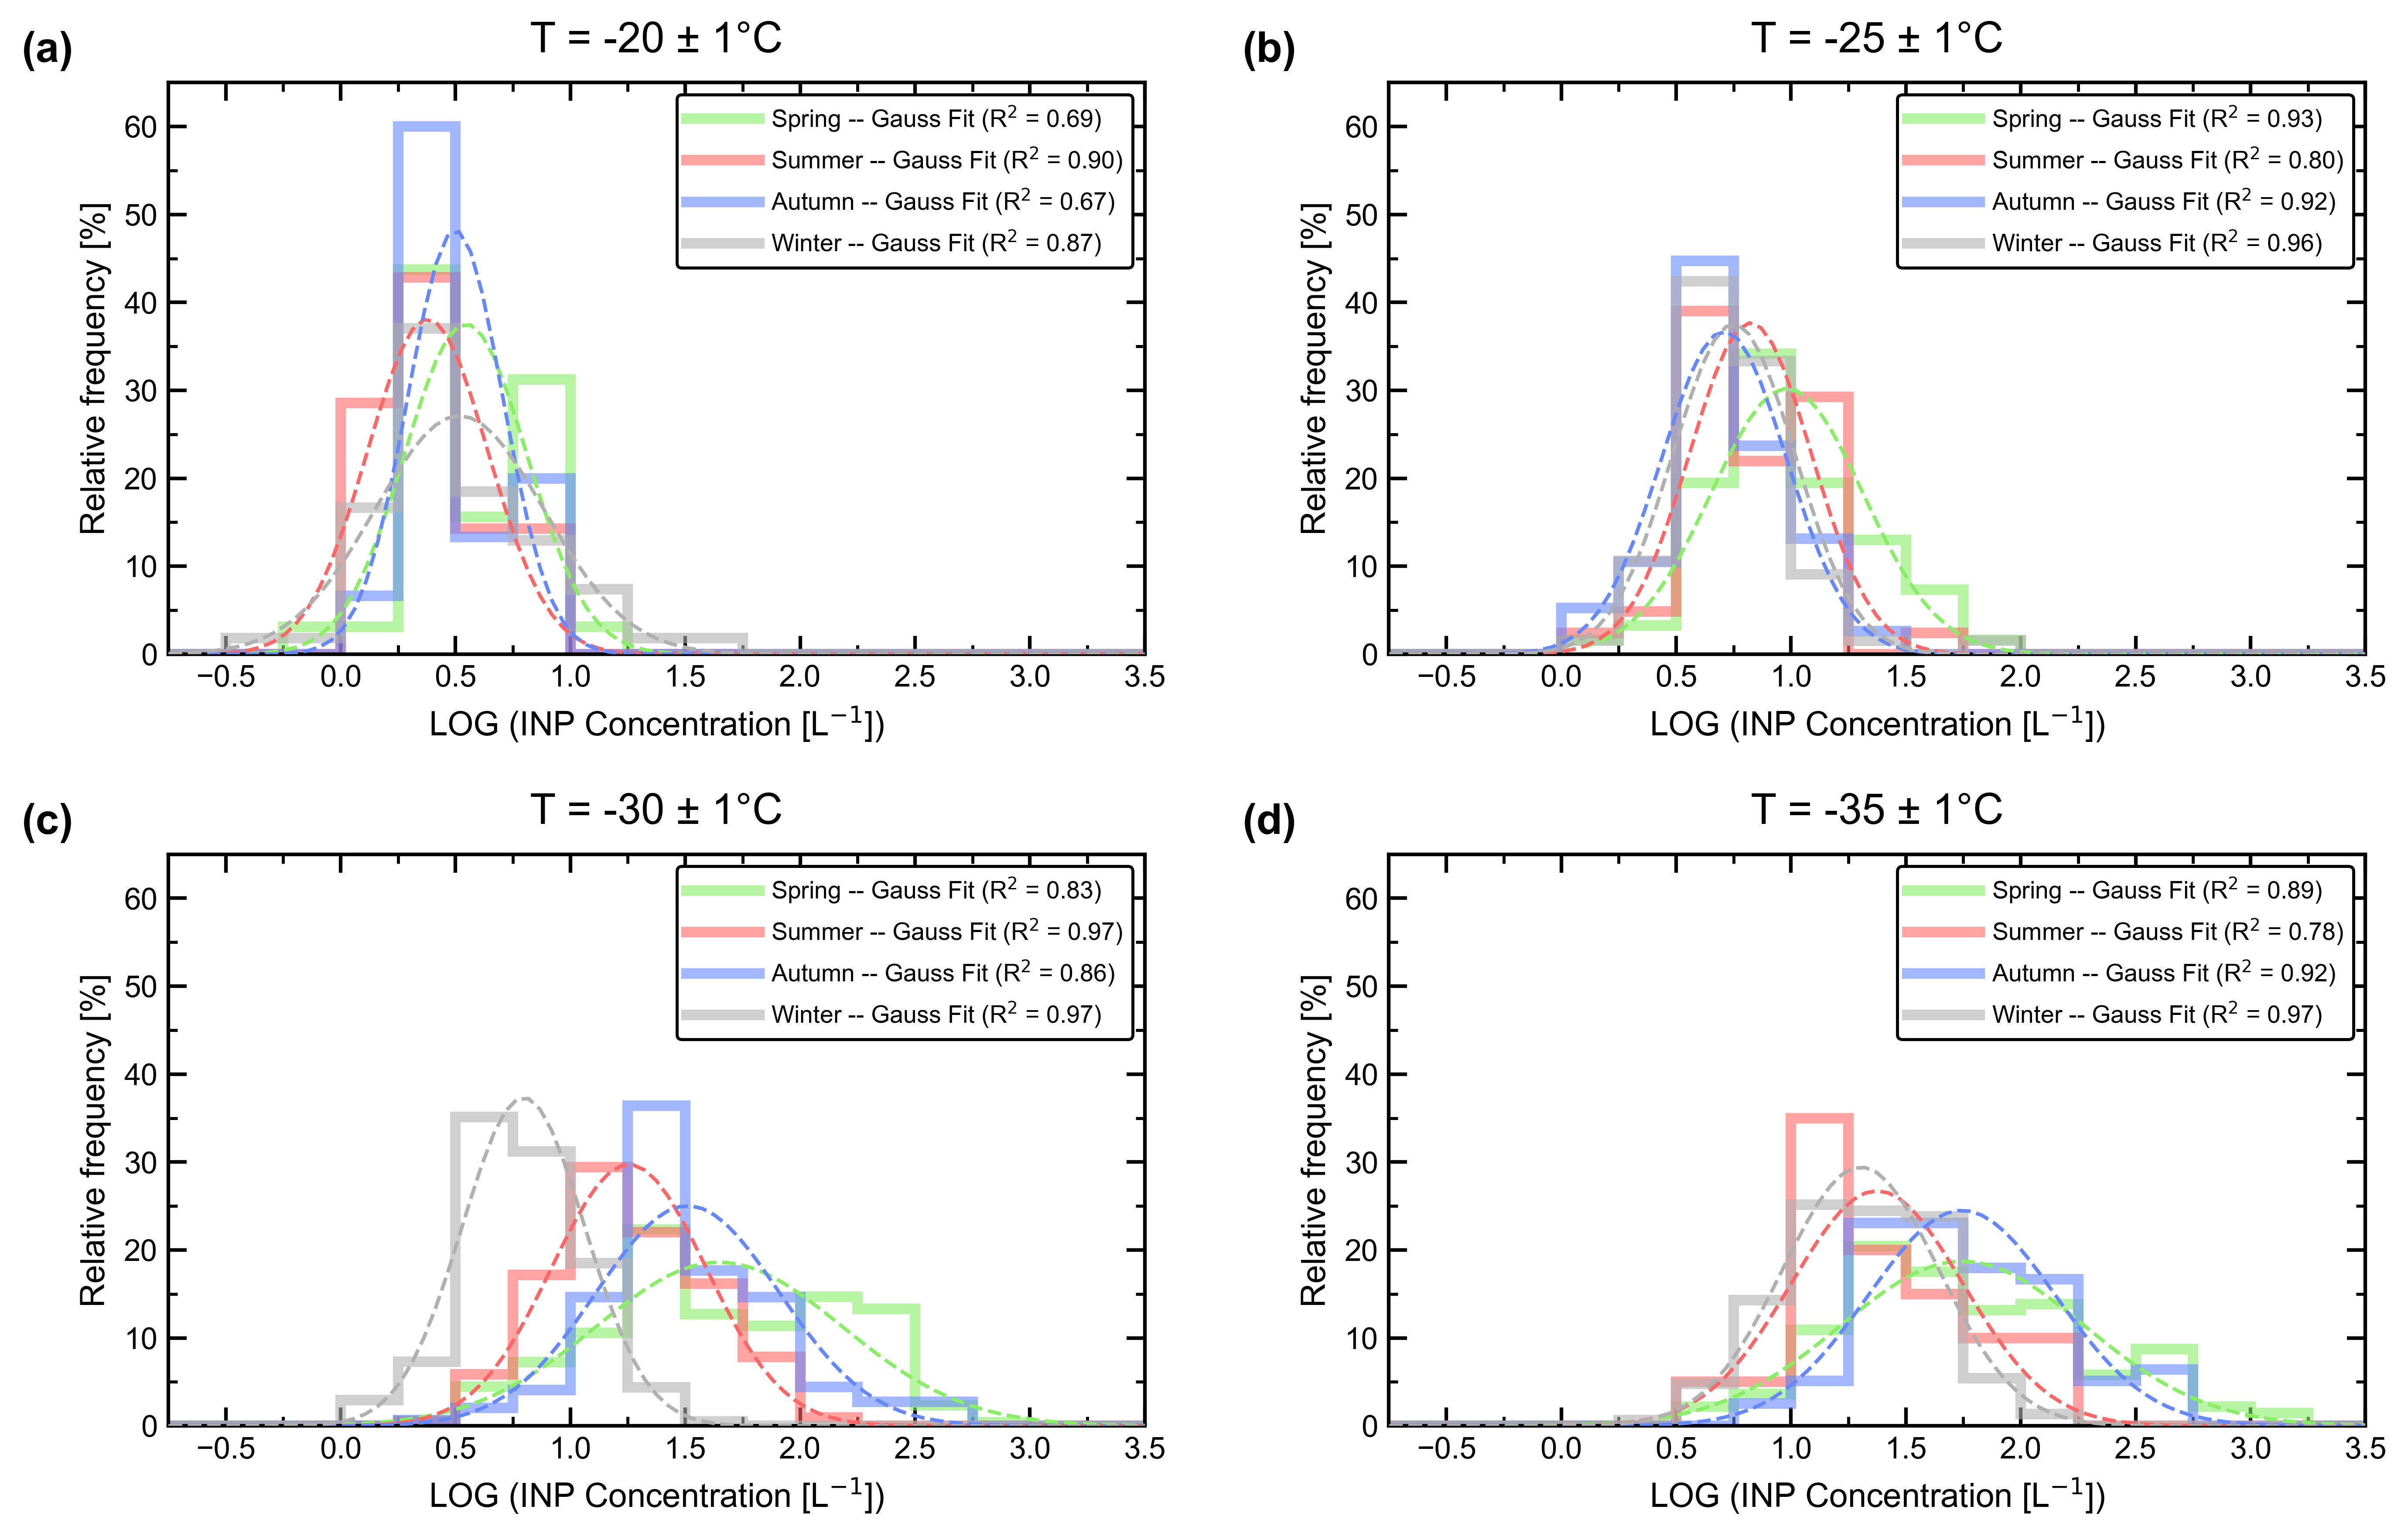

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import norm

# ==========================================
# 1. 读取数据 
# ==========================================
df = pd.read_csv(r'D:\Coding\Data\Lanzhou_cfdc\processed\N_INP(202409-202509)v2.4.1.csv')
df = df[df['Is_Significant'] == True].copy()
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
target_temps = [-20, -25, -30, -35]

# ==========================================
# 2. 绘图准备与参数设置
# ==========================================
# 设置全局字体格式
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.2 # 边框加粗

# 为四个季节分配颜色
season_colors = {
    'Spring': '#88EE66', # 绿色
    'Summer': '#FF6666', # 红色
    'Autumn': '#6688FF', # 蓝色
    'Winter': '#B0B0B0', # 灰色
}

# 2行2列排版，figsize调整为 13x8 更适合A4纸竖排
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=500) 

# 将 2x2 的二维坐标轴矩阵展平为一维列表，方便用 i 索引
axes_flat = axes.flatten() 

# 调整子图间的横向(wspace)和纵向(hspace)间距
plt.subplots_adjust(wspace=0.25, hspace=0.35) 

# ==========================================
# 全局计算 X 轴的合理范围
# ==========================================
valid_global_inp = df['N_inp_net(#/L)'][df['N_inp_net(#/L)'] > 0]
global_log_data = np.log10(valid_global_inp)
x_min_global = np.floor(global_log_data.min())
x_max_global = np.ceil(global_log_data.max())
fixed_bin_width = 0.25
bins_edges = np.arange(x_min_global, x_max_global + fixed_bin_width, fixed_bin_width)
x_fit = np.linspace(x_min_global, x_max_global, 100)

# ==========================================
# 3. 循环绘制每个子图
# ==========================================
for i, t in enumerate(target_temps):
    # 使用展平后的 axes_flat
    ax = axes_flat[i] 
    df_temp = df[df['T_a(°C)'] == t]
    
    legend_handles = []
    legend_labels = []
    
    for season in seasons:
        df_season = df_temp[df_temp['season'] == season]
        if df_season.empty:
            continue
            
        valid_inp = df_season['N_inp_net(#/L)'][df_season['N_inp_net(#/L)'] > 0]
        data_log = np.log10(valid_inp)

        if len(data_log) < 3: 
            continue
            
        color = season_colors[season]
        weights = np.ones_like(data_log) / len(data_log) * 100
        
        # 绘制直方图
        counts, bins, _ = ax.hist(data_log, bins=bins_edges, weights=weights,
                                  histtype='step', linewidth=3.5, alpha=0.6, 
                                  color=color, zorder=2)
        
        # 高斯拟合
        mu, std = norm.fit(data_log)
        pdf = norm.pdf(x_fit, mu, std)
        
        bin_width = bins[1] - bins[0]
        y_fit = pdf * bin_width * 100
        
        ax.plot(x_fit, y_fit, linestyle='--', color=color, linewidth=1.2, zorder=3)
        
        # 计算 R^2
        bin_centers = (bins[:-1] + bins[1:]) / 2
        expected_counts = norm.pdf(bin_centers, mu, std) * bin_width * 100
        ss_res = np.sum((counts - expected_counts) ** 2)
        ss_tot = np.sum((counts - np.mean(counts)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        r2 = max(0, r2) 
        
        p_hist = mlines.Line2D([], [], color=color, linewidth=3.5, alpha=0.6)
        p_fit = mlines.Line2D([], [], color=color, linestyle='--', linewidth=1.2)
        legend_handles.append((p_hist))
        
        # 为了保证排版整齐，建议给season填充空格保持等长，例如使用 {season:<6}
        legend_labels.append(f"{season:<6} -- Gauss Fit (R$^2$ = {r2:.2f})")

    # ==========================================
    # 4. 子图细节美化
    # ==========================================
    ax.set_title(f'T = {t} ± 1°C', fontsize=14, pad=10)
    ax.set_xlabel('LOG (INP Concentration [L$^{-1}$])', fontsize=11)
    ax.set_ylabel('Relative frequency [%]', fontsize=11)

    ax.set_xlim(-0.75, 3.5)
    ax.set_ylim(0, 65)
    
    ax.tick_params(axis='both', which='major', direction='in', 
                   top=True, right=True, length=6, width=1.2, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in', 
                   top=True, right=True, length=3, width=1)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    
    ax.text(-0.15, 1.02, f'({chr(97+i)})', transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='bottom', ha='left')
    
    if legend_handles:
        ax.legend(legend_handles, legend_labels, 
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
                  fontsize=8, frameon=True, 
                  edgecolor='black', framealpha=1, borderpad=0.4, 
                  handlelength=3, handletextpad=0.5)


# 5. 保存并显示
# bbox_inches='tight' 可以自动裁剪掉多余的白边
#plt.savefig('INP_Distribution_Seasons.png', dpi=600, bbox_inches='tight')
plt.show()

## n_s

### 全部数据

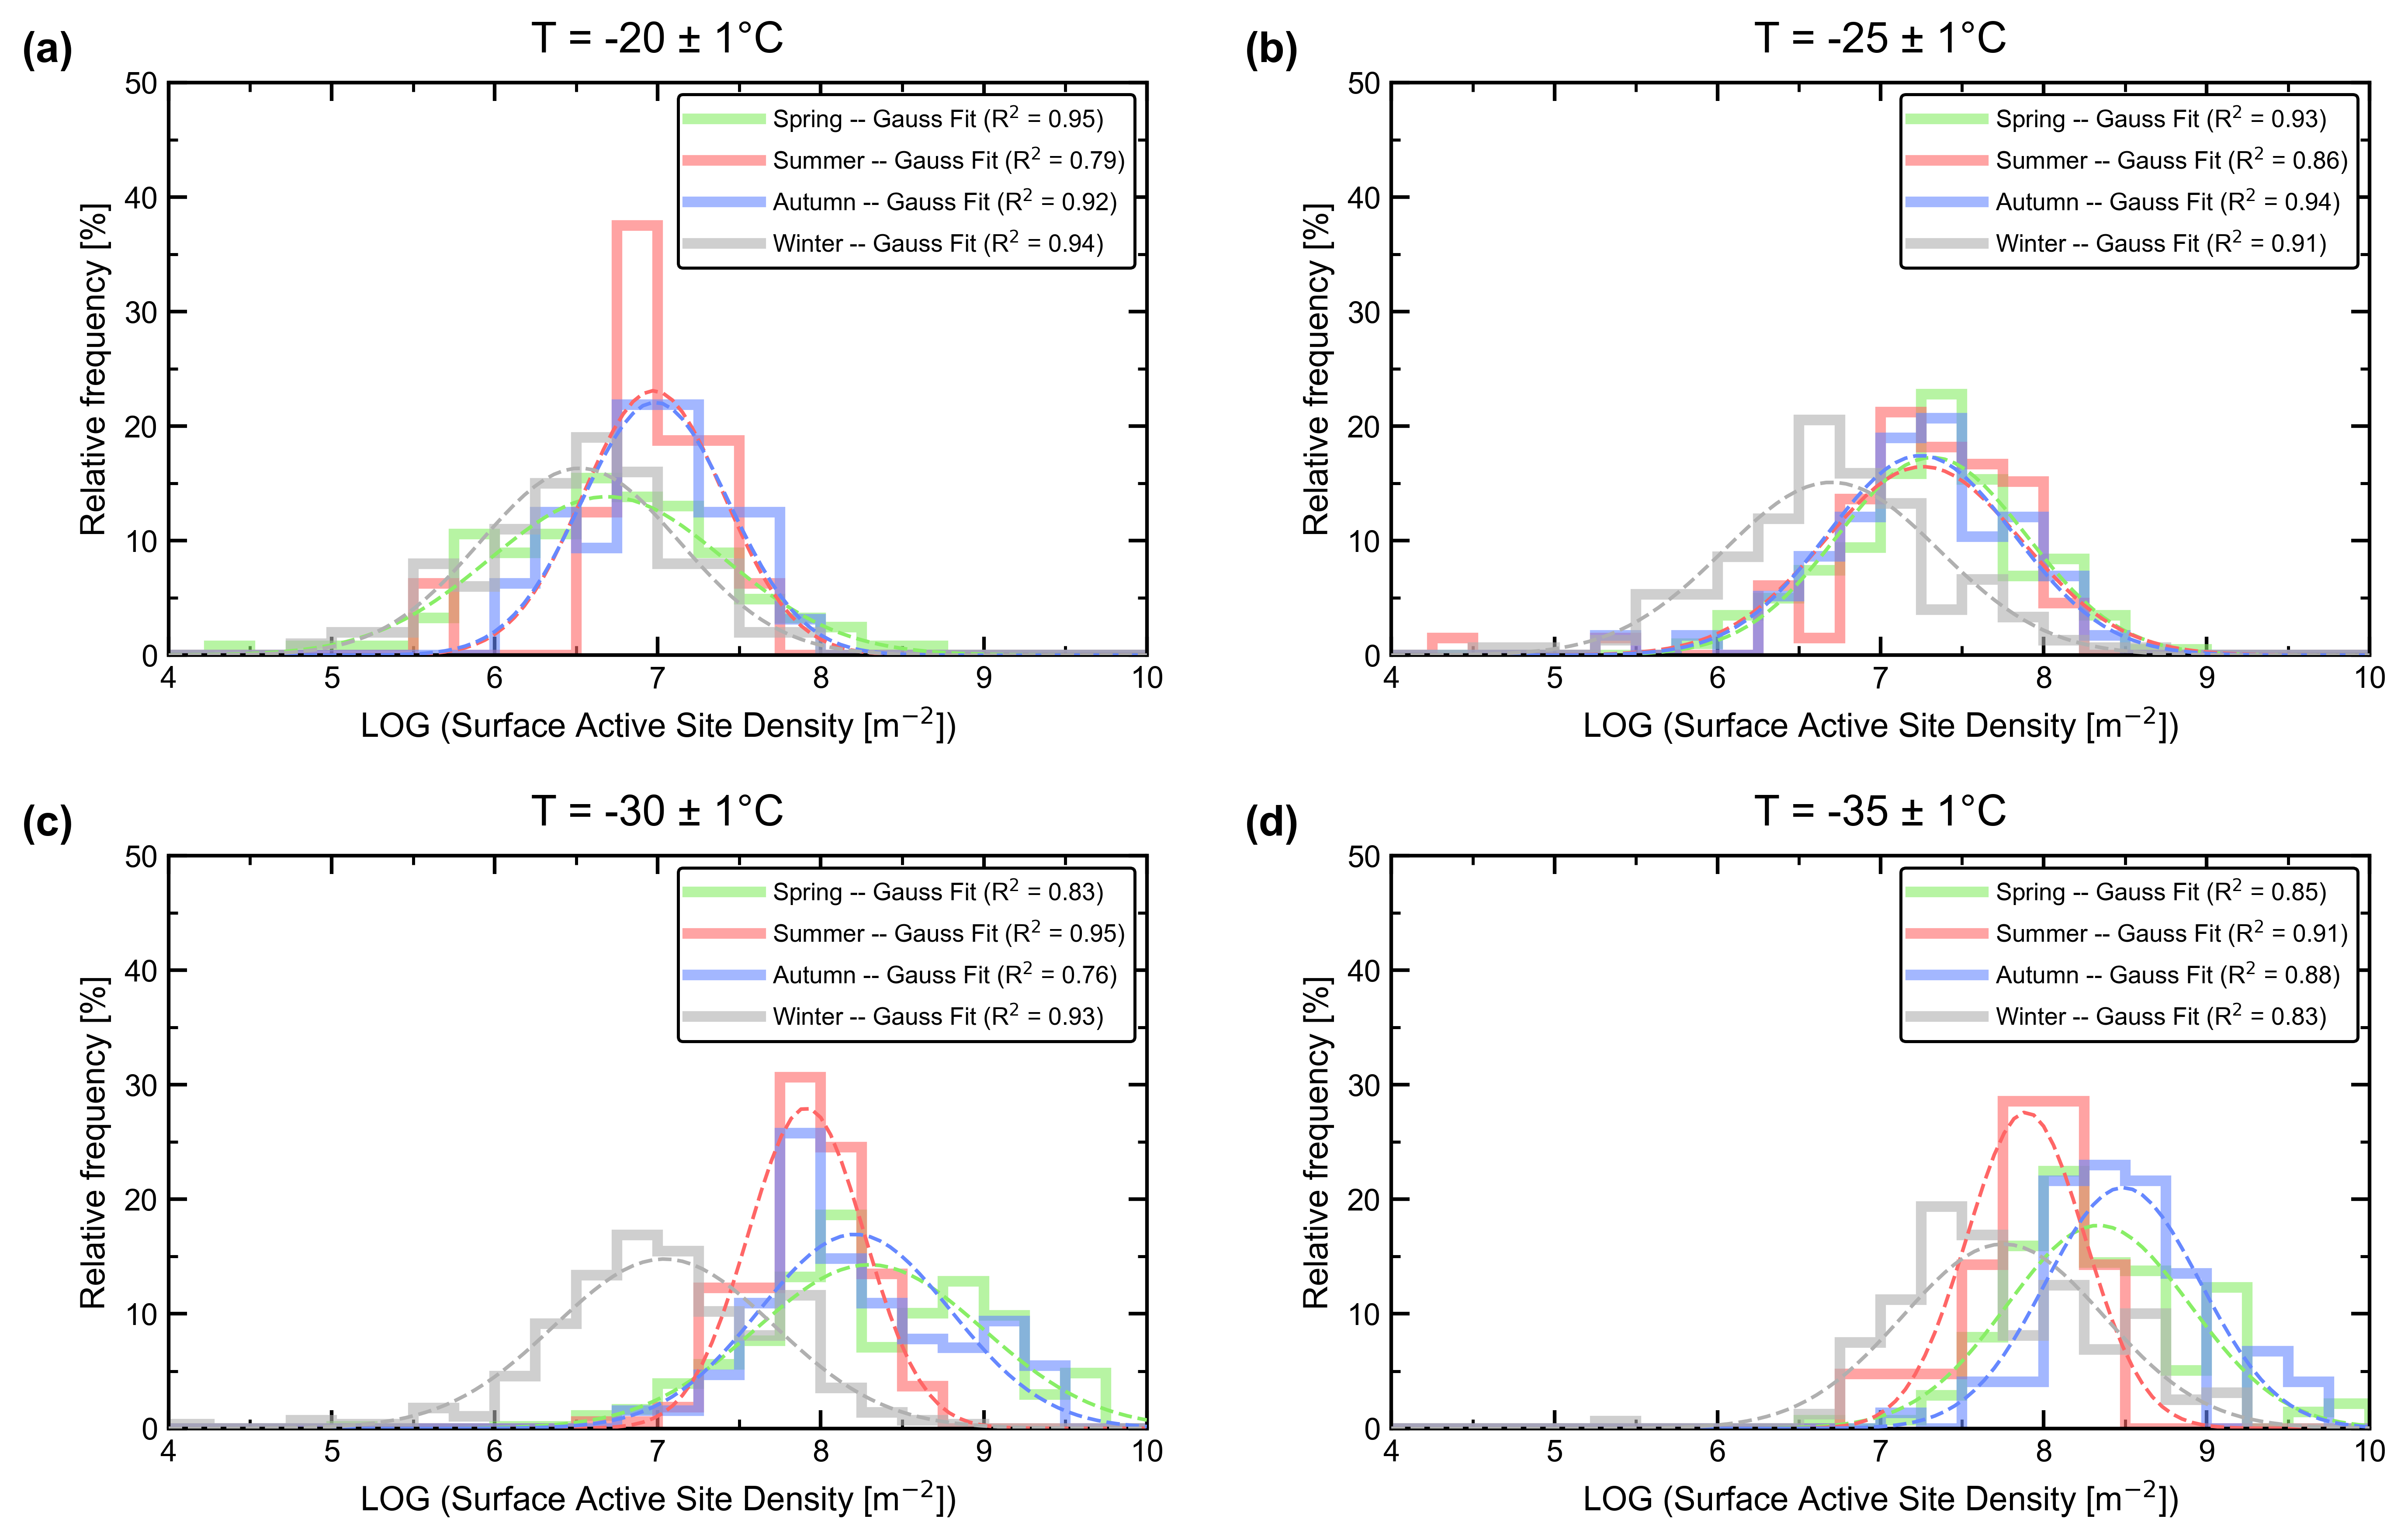

In [3]:
## 绘制`n_s`的概率密度分布

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import norm

# ==========================================
# 1. 读取数据 
# ==========================================
df = pd.read_csv(r'D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\INP+ns(v1.0.1).csv')
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
target_temps = [-20, -25, -30, -35]

# ==========================================
# 2. 绘图准备与参数设置
# ==========================================
# 设置全局字体格式
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.2 # 边框加粗

# 为四个季节分配颜色
season_colors = {
    'Spring': '#88EE66', # 绿色
    'Summer': '#FF6666', # 红色
    'Autumn': '#6688FF', # 蓝色
    'Winter': '#B0B0B0', # 灰色
}

# 2行2列排版，figsize调整为 13x8 更适合A4纸竖排
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=500) 

# 将 2x2 的二维坐标轴矩阵展平为一维列表，方便用 i 索引
axes_flat = axes.flatten() 

# 调整子图间的横向(wspace)和纵向(hspace)间距
plt.subplots_adjust(wspace=0.25, hspace=0.35) 

# ==========================================
# 全局计算 X 轴的合理范围
# ==========================================
valid_global_inp = df['n_s'][df['n_s'] > 0]
global_log_data = np.log10(valid_global_inp)
x_min_global = np.floor(global_log_data.min())
x_max_global = np.ceil(global_log_data.max())
fixed_bin_width = 0.25  
bins_edges = np.arange(x_min_global, x_max_global + fixed_bin_width, fixed_bin_width)
x_fit = np.linspace(x_min_global, x_max_global, 100)

# ==========================================
# 3. 循环绘制每个子图
# ==========================================
for i, t in enumerate(target_temps):
    # 使用展平后的 axes_flat
    ax = axes_flat[i] 
    df_temp = df[df['T_a(°C)'] == t]
    
    legend_handles = []
    legend_labels = []
    
    for season in seasons:
        df_season = df_temp[df_temp['season'] == season]
        if df_season.empty:
            continue
            
        valid_inp = df_season['n_s'][df_season['n_s'] > 0]
        data_log = np.log10(valid_inp)
        
        if len(data_log) < 3: 
            continue
            
        color = season_colors[season]
        weights = np.ones_like(data_log) / len(data_log) * 100
        
        # 绘制直方图
        counts, bins, _ = ax.hist(data_log, bins=bins_edges, weights=weights,
                                  histtype='step', linewidth=3.5, alpha=0.6, 
                                  color=color, zorder=2)
        
        # 高斯拟合
        mu, std = norm.fit(data_log)
        pdf = norm.pdf(x_fit, mu, std)
        
        bin_width = bins[1] - bins[0]
        y_fit = pdf * bin_width * 100
        
        ax.plot(x_fit, y_fit, linestyle='--', color=color, linewidth=1.2, zorder=3)
        
        # 计算 R^2
        bin_centers = (bins[:-1] + bins[1:]) / 2
        expected_counts = norm.pdf(bin_centers, mu, std) * bin_width * 100
        ss_res = np.sum((counts - expected_counts) ** 2)
        ss_tot = np.sum((counts - np.mean(counts)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        r2 = max(0, r2) 
        
        p_hist = mlines.Line2D([], [], color=color, linewidth=3.5, alpha=0.6)
        p_fit = mlines.Line2D([], [], color=color, linestyle='--', linewidth=1.2)
        legend_handles.append((p_hist))
        
        # 为了保证排版整齐，建议给season填充空格保持等长，例如使用 {season:<6}
        legend_labels.append(f"{season:<6} -- Gauss Fit (R$^2$ = {r2:.2f})")

    # ==========================================
    # 4. 子图细节美化
    # ==========================================
    ax.set_title(f'T = {t} ± 1°C', fontsize=14, pad=10)
    ax.set_xlabel('LOG (Surface Active Site Density [m$^{-2}$])', fontsize=11)
    ax.set_ylabel('Relative frequency [%]', fontsize=11)

    ax.set_xlim(x_min_global, x_max_global)
    ax.set_ylim(0, 50)
    
    ax.tick_params(axis='both', which='major', direction='in', 
                   top=True, right=True, length=6, width=1.2, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in', 
                   top=True, right=True, length=3, width=1)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    
    ax.text(-0.15, 1.02, f'({chr(97+i)})', transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='bottom', ha='left')
    
    if legend_handles:
        ax.legend(legend_handles, legend_labels, 
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
                  fontsize=8, frameon=True, 
                  edgecolor='black', framealpha=1, borderpad=0.4, 
                  handlelength=3, handletextpad=0.5)


# 5. 保存并显示
# bbox_inches='tight' 可以自动裁剪掉多余的白边
#plt.savefig('INP_Distribution_Seasons.png', dpi=600, bbox_inches='tight')
plt.show()

### 仅含显著数据点

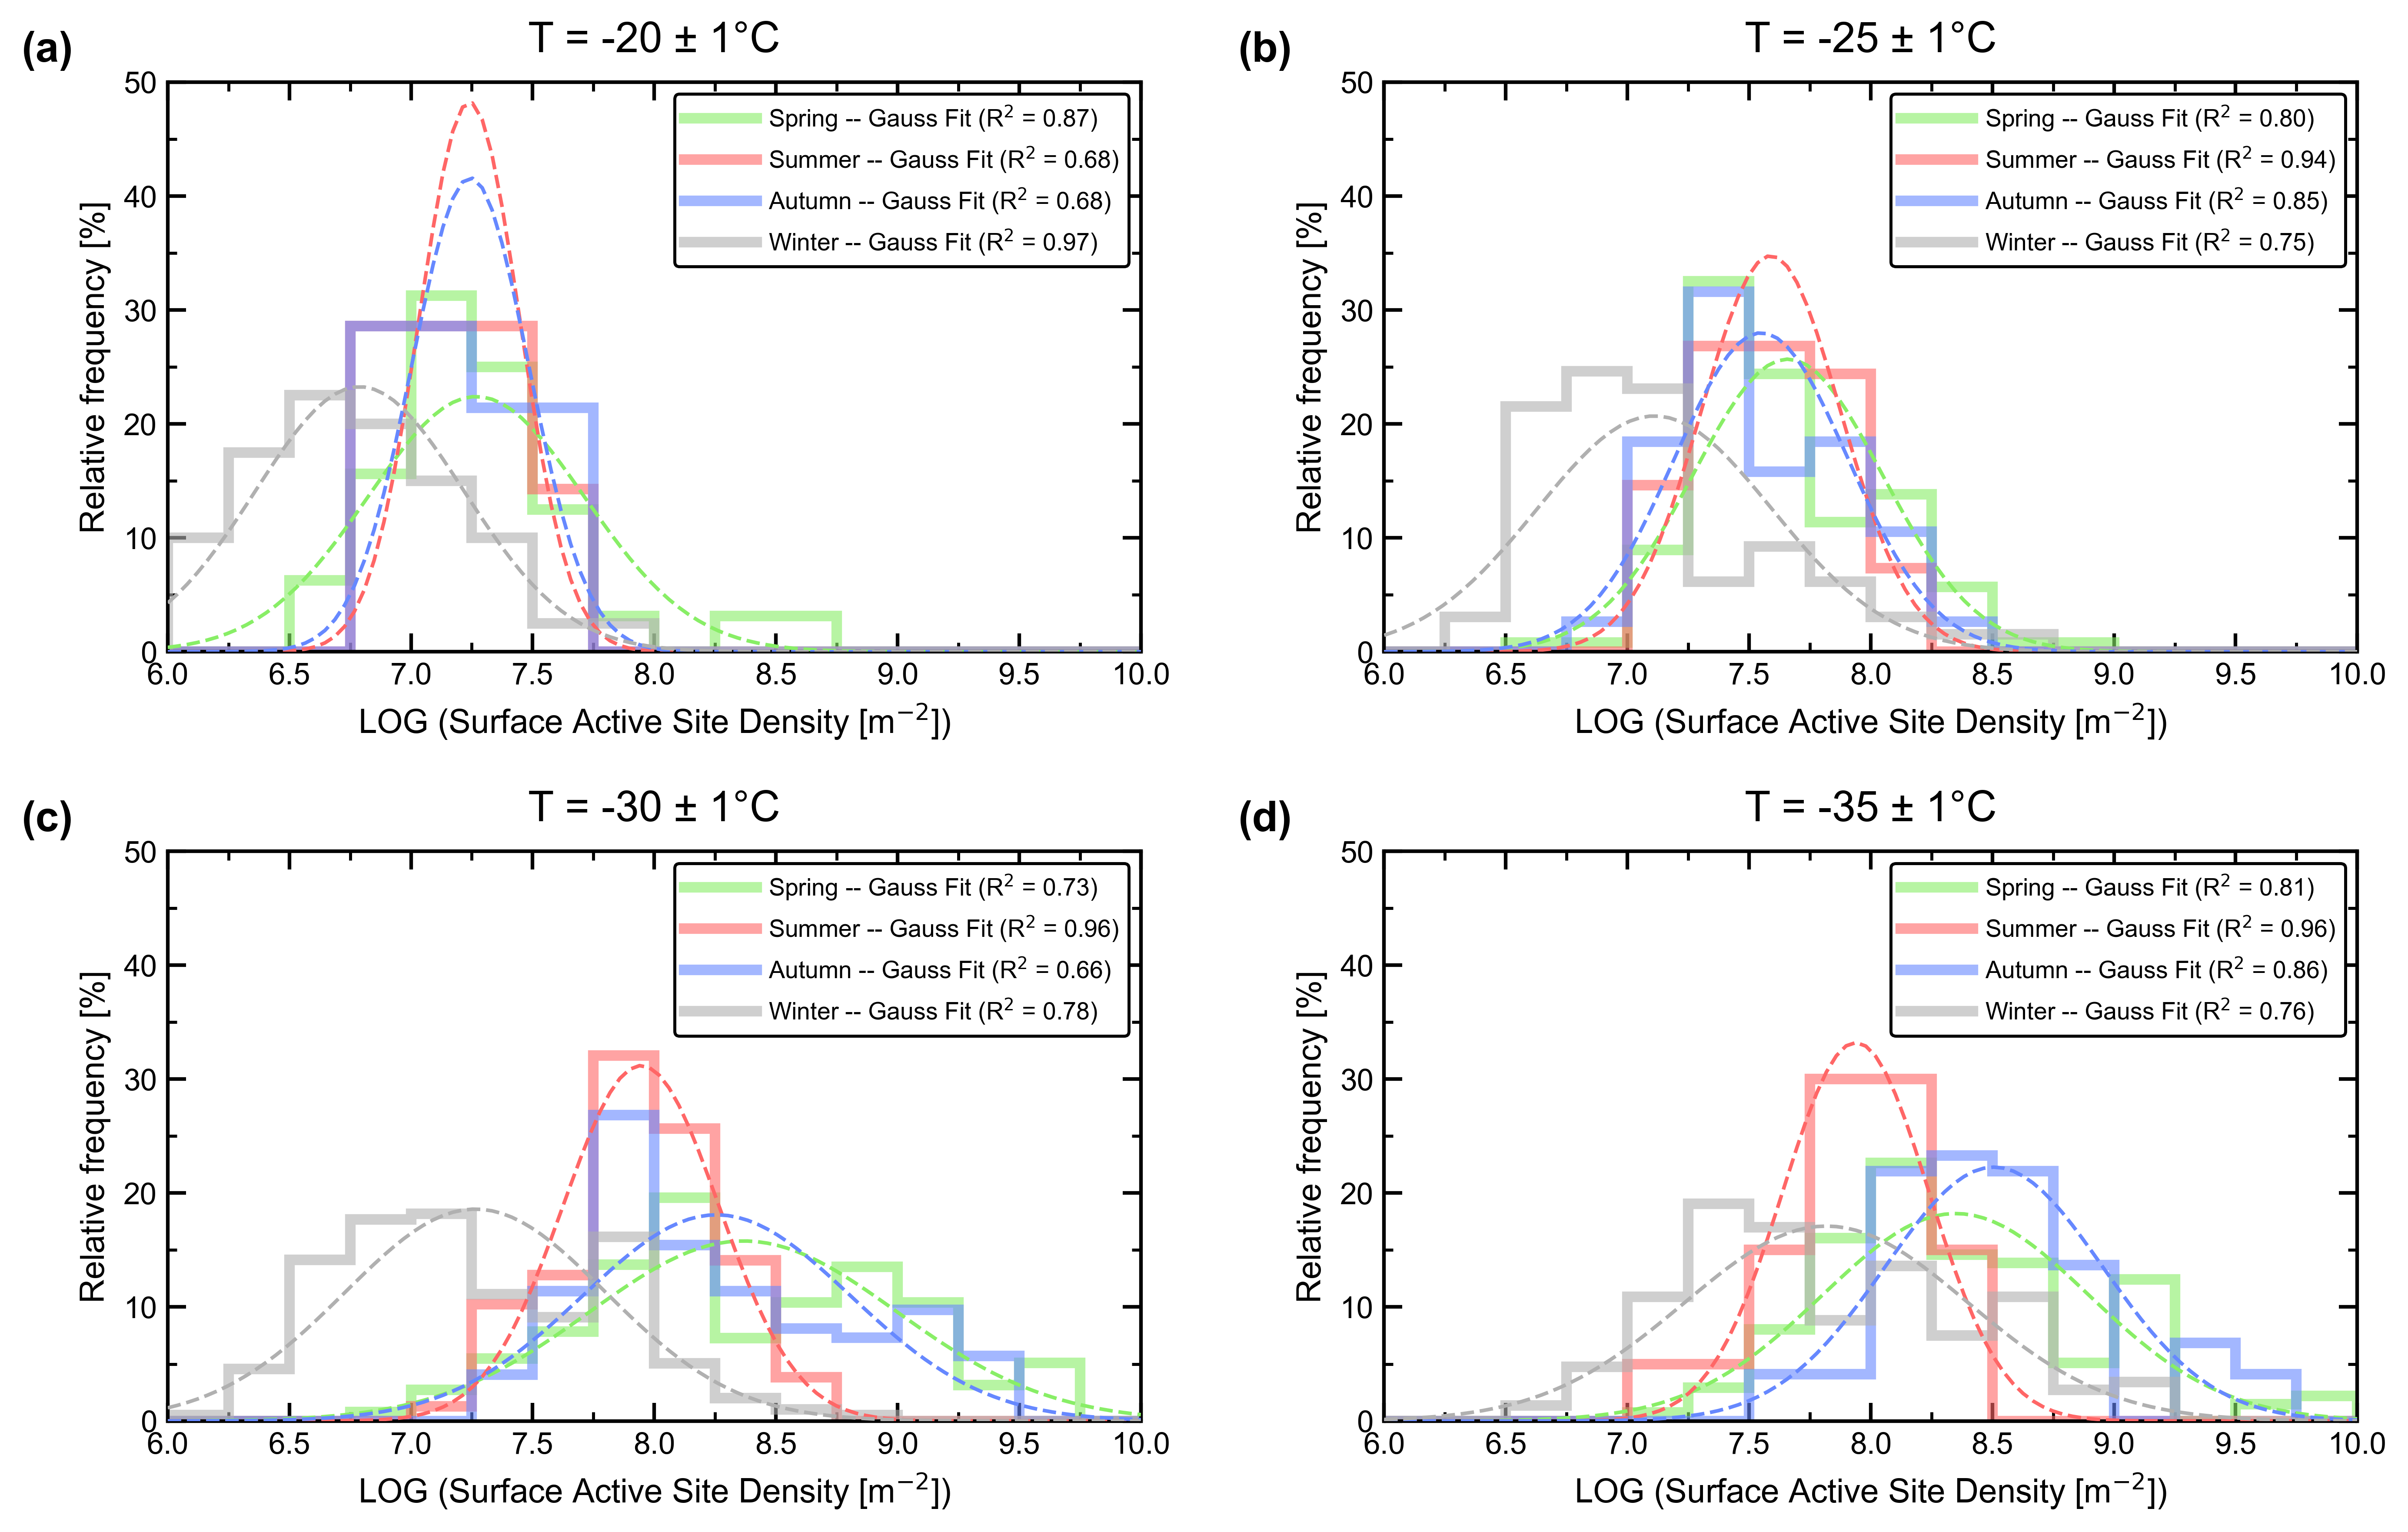

In [4]:
## 绘制`n_s`的概率密度分布

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import norm

# ==========================================
# 1. 读取数据 
# ==========================================
df = pd.read_csv(r'D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\INP+ns(v1.0.1).csv')
df = df[df['Is_Significant'] == True].copy()
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
target_temps = [-20, -25, -30, -35]

# ==========================================
# 2. 绘图准备与参数设置
# ==========================================
# 设置全局字体格式
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.2 # 边框加粗

# 为四个季节分配颜色
season_colors = {
    'Spring': '#88EE66', # 绿色
    'Summer': '#FF6666', # 红色
    'Autumn': '#6688FF', # 蓝色
    'Winter': '#B0B0B0', # 灰色
}

# 2行2列排版，figsize调整为 13x8 更适合A4纸竖排
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=500) 

# 将 2x2 的二维坐标轴矩阵展平为一维列表，方便用 i 索引
axes_flat = axes.flatten() 

# 调整子图间的横向(wspace)和纵向(hspace)间距
plt.subplots_adjust(wspace=0.25, hspace=0.35) 

# ==========================================
# 全局计算 X 轴的合理范围
# ==========================================
valid_global_inp = df['n_s'][df['n_s'] > 0]
global_log_data = np.log10(valid_global_inp)
x_min_global = np.floor(global_log_data.min())
x_max_global = np.ceil(global_log_data.max())
fixed_bin_width = 0.25  
bins_edges = np.arange(x_min_global, x_max_global + fixed_bin_width, fixed_bin_width)
x_fit = np.linspace(x_min_global, x_max_global, 100)

# ==========================================
# 3. 循环绘制每个子图
# ==========================================
for i, t in enumerate(target_temps):
    # 使用展平后的 axes_flat
    ax = axes_flat[i] 
    df_temp = df[df['T_a(°C)'] == t]
    
    legend_handles = []
    legend_labels = []
    
    for season in seasons:
        df_season = df_temp[df_temp['season'] == season]
        if df_season.empty:
            continue
            
        valid_inp = df_season['n_s'][df_season['n_s'] > 0]
        data_log = np.log10(valid_inp)
        
        if len(data_log) < 3: 
            continue
            
        color = season_colors[season]
        weights = np.ones_like(data_log) / len(data_log) * 100
        
        # 绘制直方图
        counts, bins, _ = ax.hist(data_log, bins=bins_edges, weights=weights,
                                  histtype='step', linewidth=3.5, alpha=0.6, 
                                  color=color, zorder=2)
        
        # 高斯拟合
        mu, std = norm.fit(data_log)
        pdf = norm.pdf(x_fit, mu, std)
        
        bin_width = bins[1] - bins[0]
        y_fit = pdf * bin_width * 100
        
        ax.plot(x_fit, y_fit, linestyle='--', color=color, linewidth=1.2, zorder=3)
        
        # 计算 R^2
        bin_centers = (bins[:-1] + bins[1:]) / 2
        expected_counts = norm.pdf(bin_centers, mu, std) * bin_width * 100
        ss_res = np.sum((counts - expected_counts) ** 2)
        ss_tot = np.sum((counts - np.mean(counts)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        r2 = max(0, r2) 
        
        p_hist = mlines.Line2D([], [], color=color, linewidth=3.5, alpha=0.6)
        p_fit = mlines.Line2D([], [], color=color, linestyle='--', linewidth=1.2)
        legend_handles.append((p_hist))
        
        # 为了保证排版整齐，建议给season填充空格保持等长，例如使用 {season:<6}
        legend_labels.append(f"{season:<6} -- Gauss Fit (R$^2$ = {r2:.2f})")

    # ==========================================
    # 4. 子图细节美化
    # ==========================================
    ax.set_title(f'T = {t} ± 1°C', fontsize=14, pad=10)
    ax.set_xlabel('LOG (Surface Active Site Density [m$^{-2}$])', fontsize=11)
    ax.set_ylabel('Relative frequency [%]', fontsize=11)

    ax.set_xlim(x_min_global, x_max_global)
    ax.set_ylim(0, 50)
    
    ax.tick_params(axis='both', which='major', direction='in', 
                   top=True, right=True, length=6, width=1.2, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in', 
                   top=True, right=True, length=3, width=1)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    
    ax.text(-0.15, 1.02, f'({chr(97+i)})', transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='bottom', ha='left')
    
    if legend_handles:
        ax.legend(legend_handles, legend_labels, 
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
                  fontsize=8, frameon=True, 
                  edgecolor='black', framealpha=1, borderpad=0.4, 
                  handlelength=3, handletextpad=0.5)


# 5. 保存并显示
# bbox_inches='tight' 可以自动裁剪掉多余的白边
#plt.savefig('INP_Distribution_Seasons.png', dpi=600, bbox_inches='tight')
plt.show()

### 废案

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import norm

# ==========================================
# 1. 读取数据 
# ==========================================
df = pd.read_csv(r'D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\INP+ns(outer).csv')
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
target_temps = [-15, -20, -25, -30, -35]

# ==========================================
# 2. 绘图准备与参数设置
# ==========================================
# 设置全局字体格式
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.2 # 边框加粗

# 为四个季节分配颜色 (参考原图风格：灰、红、蓝、绿)
season_colors = {
    'Spring': '#88EE66', # 绿色
    'Summer': '#FF6666', # 红色
    'Autumn': '#6688FF', # 蓝色
    'Winter': '#B0B0B0', # 灰色
}

# 1行5列排版，figsize根据需要调整。
# 提示: 如果放在A4纸论文中，1x5太长可能会看不清字，建议(20, 4)横向放置，或者改为2行3列。
fig, axes = plt.subplots(1, 5, figsize=(20, 4), dpi=500) 
plt.subplots_adjust(wspace=0.3) # 调整子图间距

# ==========================================
# 全局计算 X 轴的合理范围，保证5个子图的X轴一致，方便对比
# ==========================================
valid_global_inp = df['n_s'][df['n_s'] > 0]
global_log_data = np.log10(valid_global_inp)
# 取全局最小值和最大值
x_min_global = np.floor(global_log_data.min() * 10) / 10 - 0.5
x_max_global = np.ceil(global_log_data.max() * 10) / 10 + 0.5
# 指定固定的组距 
fixed_bin_width = 0.25  # 仿照论文, 选择0.25的组距
bins_edges = np.arange(x_min_global, x_max_global + fixed_bin_width, fixed_bin_width)
# 高斯拟合的 X 轴范围 (画平滑曲线用的，点数多一点没关系)
x_fit = np.linspace(x_min_global, x_max_global, 100)
# ------------------------

# ==========================================
# 3. 循环绘制每个子图
# ==========================================
for i, t in enumerate(target_temps):
    ax = axes[i]
    df_temp = df[df['T_a(°C)'] == t]
    
    legend_handles = []
    legend_labels = []
    
    # 记录当前子图 Y 轴的最大值，用于动态调整 Y 轴上限
    current_max_y = 0 
    
    for season in seasons:
        df_season = df_temp[df_temp['season'] == season]
        if df_season.empty:
            continue
            
        valid_inp = df_season['n_s'][df_season['n_s'] > 0]
        data_log = np.log10(valid_inp)
        
        if len(data_log) < 3: 
            continue
            
        color = season_colors[season]
        
        weights = np.ones_like(data_log) / len(data_log) * 100
        
        # 绘制直方图
        counts, bins, _ = ax.hist(data_log, bins=bins_edges, weights=weights,
                                  histtype='step', linewidth=3.5, alpha=0.6, 
                                  color=color, zorder=2)
        
        # 更新最大 Y 值 (直方图的峰值)
        current_max_y = max(current_max_y, np.max(counts))
        
        # 高斯拟合
        mu, std = norm.fit(data_log)
        pdf = norm.pdf(x_fit, mu, std)
        
        bin_width = bins[1] - bins[0]
        y_fit = pdf * bin_width * 100
        
        ax.plot(x_fit, y_fit, linestyle='--', color=color, linewidth=1.2, zorder=3)
        
        # 更新最大 Y 值 (拟合曲线的峰值)
        current_max_y = max(current_max_y, np.max(y_fit))
        
        # 计算 R^2
        bin_centers = (bins[:-1] + bins[1:]) / 2
        expected_counts = norm.pdf(bin_centers, mu, std) * bin_width * 100
        ss_res = np.sum((counts - expected_counts) ** 2)
        ss_tot = np.sum((counts - np.mean(counts)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        r2 = max(0, r2) 
        
        p_hist = mlines.Line2D([], [], color=color, linewidth=3.5, alpha=0.6)
        p_fit = mlines.Line2D([], [], color=color, linestyle='--', linewidth=1.2)
        legend_handles.append((p_hist, p_fit))
        legend_labels.append(f"{season} -- Gauss Fit (R$^2$ = {r2:.2f})")

    # ==========================================
    # 4. 子图细节美化
    # ==========================================
    ax.set_title(f'T = {t} °C', fontsize=14, pad=10)
    ax.set_xlabel('LOG (Surface Active Site Density [m$^{-2}$])', fontsize=11)
    ax.set_ylabel('Relative frequency [%]', fontsize=11)

    # 应用动态 X 轴范围
    ax.set_xlim(x_min_global, x_max_global)
    
    # 动态设置 Y 轴上限：取数据最大值的 1.35 倍 (即上方留出 35% 的空白放图例)
    if current_max_y > 0:
        ax.set_ylim(0, current_max_y * 1.35) 
    else:
        ax.set_ylim(0, 35)
    
    ax.tick_params(axis='both', which='major', direction='in', 
                   top=True, right=True, length=6, width=1.2, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in', 
                   top=True, right=True, length=3, width=1)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    
    ax.text(-0.15, 1.02, f'({chr(97+i)})', transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='bottom', ha='left')
    
    if legend_handles:
        ax.legend(legend_handles, legend_labels, 
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
                  loc='upper right', fontsize=8.5, frameon=True, 
                  edgecolor='black', framealpha=1, borderpad=0.4, 
                  handlelength=3, handletextpad=0.5)

# 5. 保存并显示
#plt.savefig('INP_Distribution_Seasons.png', dpi=600, bbox_inches='tight')
plt.show()